# XGBoost Starter - ROGII Wellbore Geology Prediction

This notebook is a compact XGBoost starter for the **ROGII - Wellbore Geology Prediction** competition. This version 3 is the same basic flow as version 2, but the residual baseline is the final known `TVT_input` value for each well.

The task is to predict `tvt` (`True Vertical Thickness`) for the hidden/evaluation interval of each horizontal well. The visible `TVT_input` column gives the known interpreted TVT before the prediction start; after that point it becomes missing and we must infer the continuation.

This starter:

- Uses only fields that are available at test time.
- Builds per-well context features from the known `TVT_input` segment.
- Adds simple Typewell gamma-ray correlation features inspired by the competition task deck.
- Uses **well-grouped K-fold validation** so rows from the same well do not leak across folds.
- Trains an XGBoost residual model over the strong last-known-`TVT_input` baseline.
- Saves `submission.csv`.

## 1. Imports and Configuration

Set `FAST_DEBUG = True` for a quick smoke test. The default is full-data 5-fold validation.

In [ ]:
from pathlib import Path
from collections import defaultdict
import os
import gc
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.model_selection import GroupKFold
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)

KAGGLE = os.path.exists('/kaggle')

RANDOM_STATE = 42
FAST_DEBUG = False
INFERENCE_MODE = False  # True: skip training, load models from MODEL_PATH

N_FOLDS = 3 if FAST_DEBUG else 5
MAX_TRAIN_WELLS = 60 if FAST_DEBUG else None

XGB_PARAMS = {
    "n_estimators": 80 if FAST_DEBUG else 450,
    "learning_rate": 0.06 if FAST_DEBUG else 0.035,
    "max_depth": 5,
    "min_child_weight": 20,
    "subsample": 0.85,
    "colsample_bytree": 0.85,
    "reg_lambda": 4.0,
    "reg_alpha": 0.05,
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "tree_method": "hist",
    "max_bin": 256,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "device": "cuda",
}

print("FAST_DEBUG:", FAST_DEBUG)
print("N_FOLDS:", N_FOLDS)
print("XGB_PARAMS:", XGB_PARAMS)

FAST_DEBUG: False
N_FOLDS: 5
XGB_PARAMS: {'n_estimators': 450, 'learning_rate': 0.035, 'max_depth': 5, 'min_child_weight': 20, 'subsample': 0.85, 'colsample_bytree': 0.85, 'reg_lambda': 4.0, 'reg_alpha': 0.05, 'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'tree_method': 'hist', 'max_bin': 256, 'random_state': 42, 'n_jobs': -1, 'device': 'cuda'}


## 2. Locate Data

The helper below works on Kaggle and with a local extracted copy of the competition data.

In [ ]:
def find_data_root():
    candidates = [
        Path("/kaggle/input/competitions/rogii-wellbore-geology-prediction"),
        Path.cwd(),
    ]
    candidates.extend(Path.cwd().parents)

    for root in candidates:
        if (root / "train").is_dir() and (root / "sample_submission.csv").is_file():
            return root.resolve()
    raise FileNotFoundError("Could not find train/ and sample_submission.csv")

DATA_ROOT = find_data_root() if KAGGLE else Path("../data")
TRAIN_DIR = DATA_ROOT / "train"
TEST_DIR = DATA_ROOT / "test"
SAMPLE_SUB_PATH = DATA_ROOT / "sample_submission.csv"
TRAIN_FEATURES_PATH = Path("train_features.parquet")
TEST_FEATURES_PATH = Path("test_features.parquet")

print("DATA_ROOT:", DATA_ROOT)
print("TRAIN_DIR:", TRAIN_DIR)
print("TEST_DIR:", TEST_DIR)

MODEL_PATH = Path("/kaggle/input/models/mateomangialomini/xgboost/other/default/2/models.pkl") if KAGGLE else Path("models.pkl")


DATA_ROOT: ../data
TRAIN_DIR: ../data/train
TEST_DIR: ../data/test


In [10]:
def well_id_from_path(path):
    return Path(path).name.split("__", 1)[0]

train_horizontal_paths = sorted(TRAIN_DIR.glob("*__horizontal_well.csv"))
test_horizontal_paths = sorted(TEST_DIR.glob("*__horizontal_well.csv"))

if MAX_TRAIN_WELLS is not None:
    train_horizontal_paths = train_horizontal_paths[:MAX_TRAIN_WELLS]

print(f"Training horizontal wells used: {len(train_horizontal_paths)}")
print(f"Visible test horizontal wells:  {len(test_horizontal_paths)}")

sample_sub = pd.read_csv(SAMPLE_SUB_PATH)
sample_sub["well_id"] = sample_sub["id"].str.rsplit("_", n=1).str[0]
sample_sub["row_index"] = sample_sub["id"].str.rsplit("_", n=1).str[1].astype(int)

display(sample_sub.head())
display(sample_sub.groupby("well_id").size().rename("rows_to_predict").reset_index().head())

Training horizontal wells used: 773
Visible test horizontal wells:  3


,id,tvt,well_id,row_index
0,000d7d20_1442,0.0,000d7d20,1442
1,000d7d20_1443,0.0,000d7d20,1443
2,000d7d20_1444,0.0,000d7d20,1444
3,000d7d20_1445,0.0,000d7d20,1445
4,000d7d20_1446,0.0,000d7d20,1446


,well_id,rows_to_predict
0,000d7d20,3836
1,00bbac68,6014
2,00e12e8b,4301


## 3. Feature Engineering

The model predicts the residual from the strongest last-known-TVT baseline we found locally:

`baseline_tvt = last_known_tvt`

A zero residual therefore equals the last-known-TVT baseline, which scored about `15.9` RMSE locally. XGBoost only needs to learn corrections away from that flat baseline.

The slope-continuation values are still kept as features:

- `baseline_tvt_all_slope`
- `baseline_tvt_recent_slope`
- `slope_tvt_md_all`
- `slope_tvt_md_recent`

Training uses only rows where `TVT_input` is missing, because those match the rows we must predict in test.

In [11]:
def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def robust_slope(x, y, default=0.0):
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 2:
        return default
    x = x[mask]
    y = y[mask]
    if np.nanstd(x) < 1e-6:
        return default
    return float(np.polyfit(x, y, 1)[0])


def safe_interp(x, xp, fp):
    xp = np.asarray(xp, dtype=np.float64)
    fp = np.asarray(fp, dtype=np.float64)
    mask = np.isfinite(xp) & np.isfinite(fp)
    if mask.sum() < 2:
        return np.full_like(np.asarray(x, dtype=np.float64), np.nan, dtype=np.float64)
    order = np.argsort(xp[mask])
    xp = xp[mask][order]
    fp = fp[mask][order]
    return np.interp(np.asarray(x, dtype=np.float64), xp, fp, left=np.nan, right=np.nan)


def make_test_row_map(submission):
    row_map = defaultdict(list)
    for well_id, row_idx in zip(submission["well_id"], submission["row_index"]):
        row_map[well_id].append(int(row_idx))
    return {k: np.array(v, dtype=np.int64) for k, v in row_map.items()}


def load_typewell(well_id, split):
    base = TRAIN_DIR if split == "train" else TEST_DIR
    path = base / f"{well_id}__typewell.csv"
    if path.exists():
        return pd.read_csv(path)
    return pd.DataFrame({"TVT": [], "GR": []})


In [12]:
import numpy as np
try:
    import cupy as cp
    xp = cp
except ImportError:
    xp = np


def run_particle_filter(
    md_eval, z_eval, gr_eval,
    tw_tvt, tw_gr,
    last_pos, last_md, ir, gr_sigma,
    n_particles=500, seed=42,
):
    xp.random.seed(seed)
    pos     = xp.random.normal(last_pos, 0.3, size=n_particles)
    rate    = xp.full(n_particles, ir)
    n       = len(md_eval)
    tvt_out = xp.empty(n)
    log_lik = 0.0
    prev_md = last_md

    for i in range(n):
        dmd     = md_eval[i] - prev_md
        rate    = 0.998 * rate + xp.random.normal(0, 0.002, n_particles)
        pos     = pos + rate * dmd + xp.random.normal(0, 0.005, n_particles)
        prev_md = md_eval[i]

        tvt_p       = pos - z_eval[i]
        expected_gr = xp.interp(tvt_p, tw_tvt, tw_gr)
        d           = (gr_eval[i] - expected_gr) / gr_sigma
        log_w       = -0.5 * d ** 2
        log_w      -= log_w.max()
        w           = xp.exp(log_w)
        w          /= w.sum()

        log_lik    += float(xp.log(xp.mean(xp.exp(-0.5 * d ** 2))))
        tvt_out[i]  = xp.dot(w, tvt_p)

        n_eff = 1.0 / xp.sum(w ** 2)
        if n_eff < n_particles / 2:
            idx  = xp.searchsorted(xp.cumsum(w), xp.random.random(n_particles))
            idx  = xp.clip(idx, 0, n_particles - 1)
            pos  = pos[idx]
            rate = rate[idx]

    return tvt_out, log_lik


def run_pf_ensemble(
    md_eval, z_eval, gr_eval,
    tw_tvt, tw_gr,
    last_pos, last_md, ir, gr_sigma,
    n_seeds=10, n_particles=10, scales=(3, 5, 8, 12),
):
    trajectories = xp.empty((n_seeds, len(md_eval)))
    log_liks     = xp.empty(n_seeds)

    for s in range(n_seeds):
        trajectories[s], log_liks[s] = run_particle_filter(
            md_eval=md_eval, z_eval=z_eval, gr_eval=gr_eval,
            tw_tvt=tw_tvt, tw_gr=tw_gr,
            last_pos=last_pos, last_md=last_md, ir=ir, gr_sigma=gr_sigma,
            n_particles=n_particles, seed=s,
        )

    results = {}
    for scale in scales:
        w = xp.exp((log_liks - log_liks.max()) / scale)
        w /= w.sum()
        results[f"pf_scale_{scale}"] = w @ trajectories

    results["pf_mean"] = trajectories.mean(axis=0)
    results["pf_std"]  = trajectories.std(axis=0)

    if xp is cp:
        results = {k: cp.asnumpy(v) for k, v in results.items()}
    return results


def run_pf_ensemble_vectorized(
    md_eval, z_eval, gr_eval,
    tw_tvt, tw_gr,
    last_pos, last_md, ir, gr_sigma,
    n_seeds=128, n_particles=500, scales=(3, 5, 8, 12),
):
    xp.random.seed(0)
    pos  = xp.random.normal(last_pos, 0.3, size=(n_seeds, n_particles))
    rate = xp.full((n_seeds, n_particles), ir)

    tw_tvt = xp.asarray(tw_tvt)
    tw_gr  = xp.asarray(tw_gr)

    n            = len(md_eval)
    trajectories = xp.empty((n_seeds, n))
    log_liks     = xp.zeros(n_seeds)
    prev_md      = last_md

    for i in range(n):
        dmd  = md_eval[i] - prev_md
        rate = 0.998 * rate + xp.random.normal(0, 0.002, (n_seeds, n_particles))
        pos  = pos + rate * dmd + xp.random.normal(0, 0.005, (n_seeds, n_particles))
        prev_md = md_eval[i]

        tvt_p       = pos - z_eval[i]
        expected_gr = xp.interp(tvt_p.ravel(), tw_tvt, tw_gr).reshape(n_seeds, n_particles)
        d           = (gr_eval[i] - expected_gr) / gr_sigma
        log_w       = -0.5 * d ** 2
        log_w      -= log_w.max(axis=1, keepdims=True)
        w           = xp.exp(log_w)
        w          /= w.sum(axis=1, keepdims=True)

        log_liks          += xp.log(xp.mean(xp.exp(-0.5 * d ** 2), axis=1))
        trajectories[:, i] = (w * tvt_p).sum(axis=1)

        n_eff = 1.0 / (w ** 2).sum(axis=1)
        stale = xp.where(n_eff < n_particles / 2)[0]
        if len(stale):
            for s in stale:
                cumw        = xp.cumsum(w[s])
                idx         = xp.clip(xp.searchsorted(cumw, xp.random.random(n_particles)), 0, n_particles - 1)
                pos[s]      = pos[s, idx]
                rate[s]     = rate[s, idx]

    results = {}
    for scale in scales:
        ww = xp.exp((log_liks - log_liks.max()) / scale)
        ww /= ww.sum()
        results[f"pf_scale_{scale}"] = ww @ trajectories

    results["pf_mean"] = trajectories.mean(axis=0)
    results["pf_std"]  = trajectories.std(axis=0)

    if xp is cp:
        results = {k: cp.asnumpy(v) for k, v in results.items()}
    return results

In [ ]:
def build_features_for_well(horizontal_path, split="train", test_row_map=None):
    well_id = well_id_from_path(horizontal_path)
    h = pd.read_csv(horizontal_path)
    tw = load_typewell(well_id, split)

    h["row_index"] = np.arange(len(h), dtype=np.int64)

    # Target/evaluation rows.
    if split == "train":
        row_mask = h["TVT_input"].isna() & h["TVT"].notna()
        selected_idx = h.index[row_mask].to_numpy(dtype=np.int64)
    else:
        if test_row_map is not None and well_id in test_row_map:
            selected_idx = test_row_map[well_id]
        else:
            selected_idx = h.index[h["TVT_input"].isna()].to_numpy(dtype=np.int64)

    if len(selected_idx) == 0:
        return pd.DataFrame()

    known = h[h["TVT_input"].notna()].copy()
    if len(known) == 0:
        # Very defensive fallback. This should not happen in the competition data.
        known = h.head(1).copy()
        known["TVT_input"] = np.nan

    first_missing = h.index[h["TVT_input"].isna()]
    ps_idx = int(first_missing[0]) if len(first_missing) else int(len(h))
    last_known = known.iloc[-1]

    # Slopes from the known segment.
    slope_all = robust_slope(known["MD"], known["TVT_input"])
    recent = known.tail(min(200, len(known)))
    slope_recent = robust_slope(recent["MD"], recent["TVT_input"], default=slope_all)
    slope_z_recent = robust_slope(recent["Z"], recent["TVT_input"])

    # Current rows.
    cur = h.loc[selected_idx, ["MD", "X", "Y", "Z", "GR", "row_index"]].copy()
    cur["well_id"] = well_id
    cur["id"] = cur["well_id"] + "_" + cur["row_index"].astype(str)

    # Per-well known-context constants.
    ps_md = float(last_known.get("MD", np.nan))
    ps_x = float(last_known.get("X", np.nan))
    ps_y = float(last_known.get("Y", np.nan))
    ps_z = float(last_known.get("Z", np.nan))
    ps_gr = float(last_known.get("GR", np.nan))
    last_known_tvt = float(last_known.get("TVT_input", np.nan))

    cur["n_rows"] = len(h)
    cur["prediction_start_index"] = ps_idx
    cur["last_known_tvt"] = last_known_tvt
    cur["known_tvt_min"] = known["TVT_input"].min()
    cur["known_tvt_max"] = known["TVT_input"].max()
    cur["known_tvt_range"] = known["TVT_input"].max() - known["TVT_input"].min()
    cur["known_tvt_mean"] = known["TVT_input"].mean()
    cur["known_tvt_std"] = known["TVT_input"].std()
    cur["known_gr_mean"] = known["GR"].mean() if "GR" in known else np.nan
    cur["known_gr_std"] = known["GR"].std() if "GR" in known else np.nan
    cur["known_gr_min"] = known["GR"].min() if "GR" in known else np.nan
    cur["known_gr_max"] = known["GR"].max() if "GR" in known else np.nan
    cur["last_known_gr"] = ps_gr
    cur["slope_tvt_md_all"] = slope_all
    cur["slope_tvt_md_recent"] = slope_recent
    cur["slope_tvt_z_recent"] = slope_z_recent

    # Relative position after prediction start.
    cur["row_from_ps"] = cur["row_index"] - ps_idx
    cur["row_frac"] = cur["row_index"] / max(len(h) - 1, 1)
    cur["md_from_ps"] = cur["MD"] - ps_md
    cur["x_from_ps"] = cur["X"] - ps_x
    cur["y_from_ps"] = cur["Y"] - ps_y
    cur["z_from_ps"] = cur["Z"] - ps_z
    cur["xy_dist_from_ps"] = np.sqrt(cur["x_from_ps"] ** 2 + cur["y_from_ps"] ** 2)
    cur["xyz_dist_from_ps"] = np.sqrt(cur["xy_dist_from_ps"] ** 2 + cur["z_from_ps"] ** 2)

    # Baselines. XGB2 uses the flat last-known-TVT baseline for residual learning.
    # The slope continuation baselines are retained only as model features.
    cur["baseline_tvt_all_slope"] = last_known_tvt + slope_all * cur["md_from_ps"]
    cur["baseline_tvt_recent_slope"] = last_known_tvt + slope_recent * cur["md_from_ps"]
    cur["baseline_tvt"] = last_known_tvt

    # Horizontal GR features. Interpolate missing GR for rolling/context features but keep a missing flag.
    cur["gr_missing"] = cur["GR"].isna().astype(np.int8)
    gr_filled = h["GR"].astype(float).interpolate(limit_direction="both")
    for window in [11, 51, 151]:
        roll = gr_filled.rolling(window=window, center=True, min_periods=max(2, window // 5))
        cur[f"gr_roll_mean_{window}"] = roll.mean().iloc[selected_idx].to_numpy()
        cur[f"gr_roll_std_{window}"] = roll.std().iloc[selected_idx].to_numpy()
    cur["gr_diff_1"] = gr_filled.diff(1).iloc[selected_idx].to_numpy()
    cur["gr_diff_10"] = gr_filled.diff(10).iloc[selected_idx].to_numpy()
    cur["gr_minus_last_known"] = cur["GR"] - ps_gr

    # Typewell features.
    if {"TVT", "GR"}.issubset(tw.columns) and len(tw) > 1:
        tw_tvt = tw["TVT"].astype(float)
        tw_gr = tw["GR"].astype(float)
        cur["typewell_tvt_min"] = tw_tvt.min()
        cur["typewell_tvt_max"] = tw_tvt.max()
        cur["typewell_tvt_range"] = tw_tvt.max() - tw_tvt.min()
        cur["typewell_gr_mean"] = tw_gr.mean()
        cur["typewell_gr_std"] = tw_gr.std()
        cur["typewell_gr_min"] = tw_gr.min()
        cur["typewell_gr_max"] = tw_gr.max()
        cur["tw_gr_at_last_known_tvt"] = safe_interp(np.array([last_known_tvt]), tw_tvt, tw_gr)[0]
        cur["tw_gr_at_baseline_tvt"] = safe_interp(cur["baseline_tvt"].to_numpy(), tw_tvt, tw_gr)
        cur["tw_gr_at_baseline_all_slope"] = safe_interp(cur["baseline_tvt_all_slope"].to_numpy(), tw_tvt, tw_gr)
        cur["gr_minus_tw_baseline"] = cur["GR"] - cur["tw_gr_at_baseline_tvt"]
        cur["gr_minus_tw_last_known"] = cur["GR"] - cur["tw_gr_at_last_known_tvt"]

        known_mask   = h["TVT_input"].notna().to_numpy()
        tail    = known.tail(30)
        dmd     = np.diff(tail["MD"].to_numpy())
        valid   = dmd > 0
        pos_ser = tail["TVT_input"].to_numpy() + h.loc[tail.index, "Z"].to_numpy()
        ir      = np.median(np.diff(pos_ser)[valid] / dmd[valid]) if valid.sum() >= 3 else 0.0

        gr_sigma = np.clip(
            np.std(gr_filled[known_mask] - np.interp(
                known["TVT_input"].to_numpy(dtype=np.float64), tw_tvt, tw_gr
            )), 10.0, 60.0
        )
        n_particles=20
        seed=42
        unknown_mask = ~known_mask
        pf = run_pf_ensemble_vectorized(
            md_eval     = h["MD"].to_numpy(dtype=np.float64)[unknown_mask],
            z_eval      = h["Z"].to_numpy(dtype=np.float64)[unknown_mask],
            gr_eval     = gr_filled.to_numpy(dtype=np.float64)[unknown_mask],
            tw_tvt      = tw_tvt,
            tw_gr       = tw_gr,
            last_pos    = last_known_tvt + ps_z,
            last_md     = ps_md,
            ir          = ir,
            gr_sigma    = gr_sigma,
            n_particles = n_particles,
        )

        # Add features only for selected_idx rows, mapped into unknown positions
        unknown_positions = np.where(unknown_mask)[0]
        sel_in_unknown = np.searchsorted(unknown_positions, selected_idx)

        for key, traj in pf.items():
            if key == "pf_std":
                cur[key] = traj[sel_in_unknown]
            else:
                cur[f"{key}_delta"] = traj[sel_in_unknown] - last_known_tvt

    else:
        for col in [
            "typewell_tvt_min", "typewell_tvt_max", "typewell_tvt_range",
            "typewell_gr_mean", "typewell_gr_std", "typewell_gr_min", "typewell_gr_max",
            "tw_gr_at_last_known_tvt", "tw_gr_at_baseline_tvt", "tw_gr_at_baseline_all_slope",
            "gr_minus_tw_baseline", "gr_minus_tw_last_known", "pf_mean_delta", "pf_std"
        ] + [f"pf_scale_{s}_delta" for s in (3,5,8,12)]:
            cur[col] = np.nan

    if split == "train":
        cur["target_tvt"] = h.loc[selected_idx, "TVT"].to_numpy()
        cur["target_residual"] = cur["target_tvt"] - cur["baseline_tvt"]

    # Downcast numeric columns to reduce memory.
    for col in cur.columns:
        if col not in ["well_id", "id"]:
            cur[col] = pd.to_numeric(cur[col], downcast="float")

    return cur.reset_index(drop=True)

## 4. Build Training Matrix

In [16]:
if not INFERENCE_MODE:
    if TRAIN_FEATURES_PATH.exists():
        train_df = pd.read_parquet(TRAIN_FEATURES_PATH)
        print("Loaded train_df.")
    else:
        train_parts = []
        for path in tqdm(train_horizontal_paths, desc="Train wells"):
            train_parts.append(bu+ild_features_for_well(path, split="train"))

        train_df = pd.concat(train_parts, ignore_index=True)
        del train_parts
        gc.collect()
        train_df.to_parquet(TRAIN_FEATURES_PATH, index=False)
        print("Built and saved train_df.")
    print("train_df shape:", train_df.shape)
    display(train_df.head())
    print("Target rows:", len(train_df))
    print("Unique wells:", train_df["well_id"].nunique())

Train wells: 100%|██████████| 773/773 [33:42<00:00,  2.62s/it]


train_df shape: (3783989, 65)


,MD,X,Y,Z,GR,row_index,well_id,id,n_rows,prediction_start_index,last_known_tvt,known_tvt_min,known_tvt_max,known_tvt_range,known_tvt_mean,known_tvt_std,known_gr_mean,known_gr_std,known_gr_min,known_gr_max,last_known_gr,slope_tvt_md_all,slope_tvt_md_recent,slope_tvt_z_recent,row_from_ps,row_frac,md_from_ps,x_from_ps,y_from_ps,z_from_ps,xy_dist_from_ps,xyz_dist_from_ps,baseline_tvt_all_slope,baseline_tvt_recent_slope,baseline_tvt,gr_missing,gr_roll_mean_11,gr_roll_std_11,gr_roll_mean_51,gr_roll_std_51,gr_roll_mean_151,gr_roll_std_151,gr_diff_1,gr_diff_10,gr_minus_last_known,typewell_tvt_min,typewell_tvt_max,typewell_tvt_range,typewell_gr_mean,typewell_gr_std,typewell_gr_min,typewell_gr_max,tw_gr_at_last_known_tvt,tw_gr_at_baseline_tvt,tw_gr_at_baseline_all_slope,gr_minus_tw_baseline,gr_minus_tw_last_known,pf_scale_3_delta,pf_scale_5_delta,pf_scale_8_delta,pf_scale_12_delta,pf_mean_delta,pf_std,target_tvt,target_residual
0,12909.0,2983537.06,1070212.72,-9735.070312,NaN,1442.0,000d7d20,000d7d20_1442,5278.0,1442.0,11747.370117,11236.019531,11756.120117,520.099976,11646.417969,148.869553,87.416512,22.017109,31.765827,171.643753,NaN,0.302656,0.000257,-0.048643,0.0,0.273261,1.0,-0.03,1.00,0.01,1.000450,1.000500,11747.672852,11747.370117,11747.370117,1,105.311470,0.890245,103.299164,4.825131,98.586723,14.259318,-0.205555,1.473982,NaN,11223.950195,11871.450195,647.5,83.257637,26.25132,28.66,158.179993,93.312401,93.312401,95.444763,NaN,NaN,0.006722,0.008344,0.012750,0.019568,0.034101,0.014197,11747.379883,0.01
1,12910.0,2983537.03,1070213.72,-9735.059570,NaN,1443.0,000d7d20,000d7d20_1443,5278.0,1442.0,11747.370117,11236.019531,11756.120117,520.099976,11646.417969,148.869553,87.416512,22.017109,31.765827,171.643753,NaN,0.302656,0.000257,-0.048643,1.0,0.273451,2.0,-0.06,2.00,0.02,2.000900,2.001000,11747.975586,11747.370117,11747.370117,1,105.036865,0.962581,102.871223,4.878050,98.374031,14.315206,-0.205555,0.591598,NaN,11223.950195,11871.450195,647.5,83.257637,26.25132,28.66,158.179993,93.312401,93.312401,97.856438,NaN,NaN,0.016707,0.018325,0.022713,0.029493,0.043968,0.014167,11747.389648,0.02
2,12911.0,2983537.00,1070214.72,-9735.049805,NaN,1444.0,000d7d20,000d7d20_1444,5278.0,1442.0,11747.370117,11236.019531,11756.120117,520.099976,11646.417969,148.869553,87.416512,22.017109,31.765827,171.643753,NaN,0.302656,0.000257,-0.048643,2.0,0.273640,3.0,-0.09,3.00,0.03,3.001350,3.001500,11748.278320,11747.371094,11747.370117,1,104.757362,1.017637,102.427391,4.973273,98.155296,14.380600,-0.205555,-0.290786,NaN,11223.950195,11871.450195,647.5,83.257637,26.25132,28.66,158.179993,93.312401,93.312401,98.770462,NaN,NaN,0.026286,0.027935,0.032381,0.039212,0.053738,0.014136,11747.400391,0.03
3,12912.0,2983536.97,1070215.71,-9735.040039,104.818207,1445.0,000d7d20,000d7d20_1445,5278.0,1442.0,11747.370117,11236.019531,11756.120117,520.099976,11646.417969,148.869553,87.416512,22.017109,31.765827,171.643753,NaN,0.302656,0.000257,-0.048643,3.0,0.273830,4.0,-0.12,3.99,0.04,3.991804,3.992004,11748.581055,11747.371094,11747.370117,0,104.472954,1.056209,101.967651,5.109817,97.930534,14.455724,-0.205555,-1.173170,NaN,11223.950195,11871.450195,647.5,83.257637,26.25132,28.66,158.179993,93.312401,93.312401,98.563736,11.505805,11.505805,0.036128,0.037785,0.042235,0.049041,0.063419,0.014136,11747.400391,0.03
4,12913.0,2983536.94,1070216.71,-9735.030273,103.960892,1446.0,000d7d20,000d7d20_1446,5278.0,1442.0,11747.370117,11236.019531,11756.120117,520.099976,11646.417969,148.869553,87.416512,22.017109,31.765827,171.643753,NaN,0.302656,0.000257,-0.048643,4.0,0.274019,5.0,-0.15,4.99,0.05,4.992254,4.992505,11748.882812,11747.371094,11747.370117,0,104.137505,1.157626,101.492012,5.285673,97.699738,14.540770,-0.857316,-2.707315,NaN,11223.950195,11871.450195,647.5,83.257637,26.25132,28.66,158.179993,93.312401,93.312401,96.880966,10.648488,10.648488,0.044240,0.045880,0.050294,0.057066,0.071417,0.014063,11747.410156,0.04


Target rows: 3783989
Unique wells: 773


In [18]:
if not INFERENCE_MODE:
    exclude_cols = {"well_id", "id", "target_tvt", "target_residual"}
    feature_cols = [c for c in train_df.columns if c not in exclude_cols]

    X = train_df[feature_cols].astype(np.float32)
    y_resid = train_df["target_residual"].astype(np.float32)
    y_true = train_df["target_tvt"].astype(np.float32)
    baseline = train_df["baseline_tvt"].astype(np.float32)
    groups = train_df["well_id"].values

    print(f"Number of features: {len(feature_cols)}")
    print(feature_cols)

Number of features: 61
['MD', 'X', 'Y', 'Z', 'GR', 'row_index', 'n_rows', 'prediction_start_index', 'last_known_tvt', 'known_tvt_min', 'known_tvt_max', 'known_tvt_range', 'known_tvt_mean', 'known_tvt_std', 'known_gr_mean', 'known_gr_std', 'known_gr_min', 'known_gr_max', 'last_known_gr', 'slope_tvt_md_all', 'slope_tvt_md_recent', 'slope_tvt_z_recent', 'row_from_ps', 'row_frac', 'md_from_ps', 'x_from_ps', 'y_from_ps', 'z_from_ps', 'xy_dist_from_ps', 'xyz_dist_from_ps', 'baseline_tvt_all_slope', 'baseline_tvt_recent_slope', 'baseline_tvt', 'gr_missing', 'gr_roll_mean_11', 'gr_roll_std_11', 'gr_roll_mean_51', 'gr_roll_std_51', 'gr_roll_mean_151', 'gr_roll_std_151', 'gr_diff_1', 'gr_diff_10', 'gr_minus_last_known', 'typewell_tvt_min', 'typewell_tvt_max', 'typewell_tvt_range', 'typewell_gr_mean', 'typewell_gr_std', 'typewell_gr_min', 'typewell_gr_max', 'tw_gr_at_last_known_tvt', 'tw_gr_at_baseline_tvt', 'tw_gr_at_baseline_all_slope', 'gr_minus_tw_baseline', 'gr_minus_tw_last_known', 'pf_scal

## 5. Well-Grouped K-Fold Validation

This validation splits by well ID. That is stricter and more realistic than random row K-fold because rows from the same well are highly correlated.

In [19]:
if not INFERENCE_MODE:

    gkf = GroupKFold(n_splits=N_FOLDS)
    oof = np.zeros(len(train_df), dtype=np.float32)
    fold_rows = []
    models = []

    for fold, (trn_idx, val_idx) in enumerate(gkf.split(X, y_resid, groups), start=1):
        print(f"n===== Fold {fold}/{N_FOLDS} =====")
        print(f"Train rows: {len(trn_idx):,} | Valid rows: {len(val_idx):,}")
        print(f"Train wells: {len(np.unique(groups[trn_idx])):,} | Valid wells: {len(np.unique(groups[val_idx])):,}")

        model = XGBRegressor(**XGB_PARAMS)
        model.fit(
            X.iloc[trn_idx],
            y_resid.iloc[trn_idx],
            eval_set=[(X.iloc[val_idx], y_resid.iloc[val_idx])],
            verbose=100,
        )

        val_resid_pred = model.predict(X.iloc[val_idx]).astype(np.float32)
        val_pred = baseline.iloc[val_idx].to_numpy() + val_resid_pred
        oof[val_idx] = val_pred

        fold_rmse = rmse(y_true.iloc[val_idx], val_pred)
        baseline_rmse = rmse(y_true.iloc[val_idx], baseline.iloc[val_idx])

        fold_rows.append({
            "fold": fold,
            "valid_rows": len(val_idx),
            "valid_wells": len(np.unique(groups[val_idx])),
            "baseline_rmse": baseline_rmse,
            "xgb_rmse": fold_rmse,
            "improvement": baseline_rmse - fold_rmse,
        })
        models.append(model)

        print(f"Fold {fold} baseline RMSE: {baseline_rmse:.5f}")
        print(f"Fold {fold} XGB RMSE:      {fold_rmse:.5f}")

    cv = pd.DataFrame(fold_rows)
    display(cv)
    print(f"OOF baseline RMSE: {rmse(y_true, baseline):.5f}")
    print(f"OOF XGB RMSE:      {rmse(y_true, oof):.5f}")
    print(f"Mean fold RMSE:    {cv['xgb_rmse'].mean():.5f} +/- {cv['xgb_rmse'].std():.5f}")

    joblib.dump({"models": models, "feature_cols": feature_cols}, MODEL_PATH)
    print(f"Saved {len(models)} models to {MODEL_PATH}")

else: 
    checkpoint = joblib.load(MODEL_PATH)
    models = checkpoint["models"]
    feature_cols = checkpoint["feature_cols"]
    print(f"Loaded {len(models)} models from {MODEL_PATH}")


n===== Fold 1/5 =====
Train rows: 3,026,251 | Valid rows: 757,738
Train wells: 618 | Valid wells: 155
[0]	validation_0-rmse:15.05195
[100]	validation_0-rmse:13.36726
[200]	validation_0-rmse:13.33558
[300]	validation_0-rmse:13.26744
[400]	validation_0-rmse:13.24131
[449]	validation_0-rmse:13.23924
Fold 1 baseline RMSE: 15.29015
Fold 1 XGB RMSE:      13.23924
n===== Fold 2/5 =====
Train rows: 3,027,339 | Valid rows: 756,650
Train wells: 618 | Valid wells: 155
[0]	validation_0-rmse:15.57391
[100]	validation_0-rmse:13.38956
[200]	validation_0-rmse:13.15678
[300]	validation_0-rmse:13.13244
[400]	validation_0-rmse:13.16525
[449]	validation_0-rmse:13.15192
Fold 2 baseline RMSE: 15.91725
Fold 2 XGB RMSE:      13.15190
n===== Fold 3/5 =====
Train rows: 3,027,734 | Valid rows: 756,255
Train wells: 619 | Valid wells: 154
[0]	validation_0-rmse:14.54904
[100]	validation_0-rmse:13.02830
[200]	validation_0-rmse:12.94364
[300]	validation_0-rmse:12.95388
[400]	validation_0-rmse:12.95495
[449]	validatio

,fold,valid_rows,valid_wells,baseline_rmse,xgb_rmse,improvement
0,1,757738,155,15.290149,13.239239,2.050909
1,2,756650,155,15.917252,13.151900,2.765352
2,3,756255,154,14.678227,12.931433,1.746795
3,4,757101,155,16.046960,13.448529,2.598430
4,5,756245,154,17.479987,15.429765,2.050222


OOF baseline RMSE: 15.90987
OOF XGB RMSE:      13.67022
Mean fold RMSE:    13.64017 +/- 1.01745
Saved 5 models to models.pkl


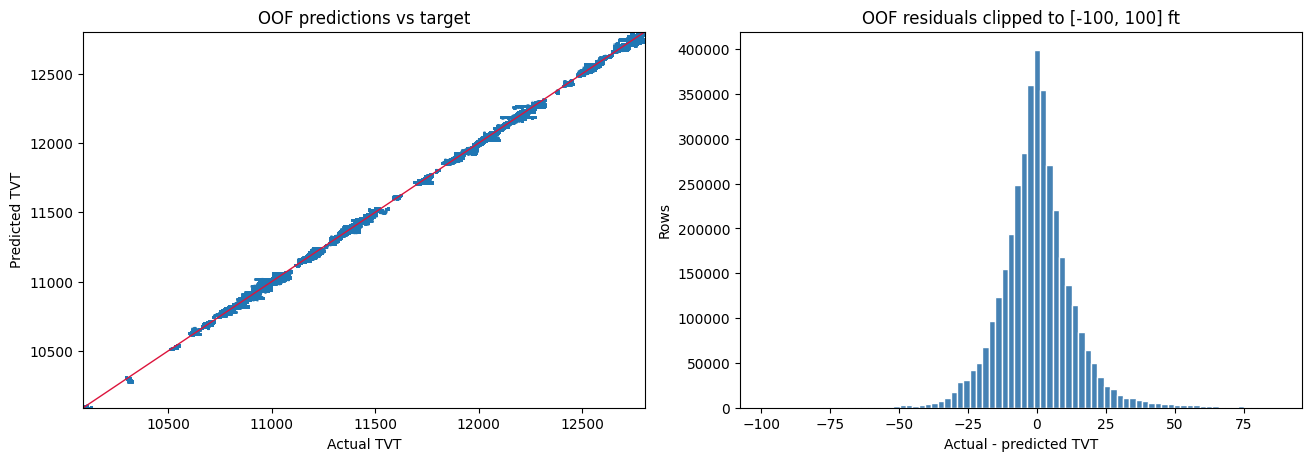

In [20]:
if not INFERENCE_MODE:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)

    axes[0].scatter(y_true, oof, s=1, alpha=0.08)
    lo = float(np.nanpercentile(y_true, 1))
    hi = float(np.nanpercentile(y_true, 99))
    axes[0].plot([lo, hi], [lo, hi], color="crimson", lw=1)
    axes[0].set_xlim(lo, hi)
    axes[0].set_ylim(lo, hi)
    axes[0].set_title("OOF predictions vs target")
    axes[0].set_xlabel("Actual TVT")
    axes[0].set_ylabel("Predicted TVT")

    resid = y_true.to_numpy() - oof
    axes[1].hist(np.clip(resid, -100, 100), bins=80, color="steelblue", edgecolor="white")
    axes[1].set_title("OOF residuals clipped to [-100, 100] ft")
    axes[1].set_xlabel("Actual - predicted TVT")
    axes[1].set_ylabel("Rows")
    plt.show()

,feature,fold_1,fold_2,fold_3,fold_4,fold_5,mean_importance
58,pf_scale_12_delta,0.187152,0.166239,0.156568,0.170690,0.141247,0.164379
57,pf_scale_8_delta,0.068411,0.054124,0.066766,0.068628,0.053772,0.062340
44,typewell_tvt_max,0.024454,0.045133,0.058875,0.020400,0.094725,0.048717
59,pf_mean_delta,0.034365,0.025208,0.019613,0.026385,0.026337,0.026382
13,known_tvt_std,0.020015,0.031449,0.026797,0.021491,0.025697,0.025090
10,known_tvt_max,0.015595,0.031982,0.029433,0.029793,0.018210,0.025003
21,slope_tvt_z_recent,0.024803,0.021541,0.021515,0.018182,0.034366,0.024082
45,typewell_tvt_range,0.024495,0.019900,0.016819,0.027414,0.026586,0.023043
32,baseline_tvt,0.013289,0.023548,0.033039,0.021348,0.023665,0.022978
20,slope_tvt_md_recent,0.022231,0.019368,0.022238,0.023290,0.027235,0.022872


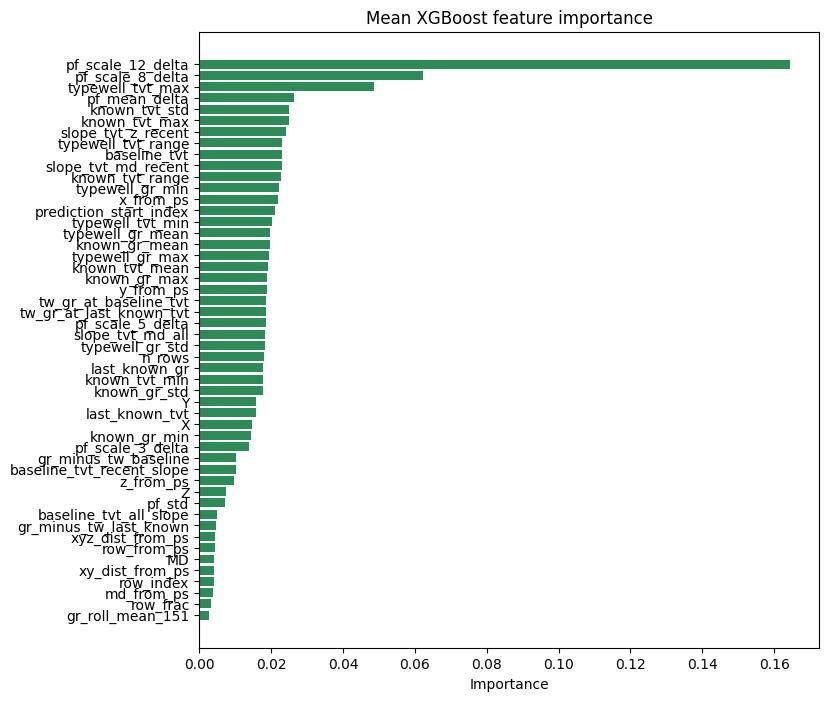

In [21]:
# Average feature importance over folds.
if not INFERENCE_MODE:
    importance = pd.DataFrame({"feature": feature_cols})
    for fold, model in enumerate(models, start=1):
        importance[f"fold_{fold}"] = model.feature_importances_
    importance["mean_importance"] = importance[[c for c in importance.columns if c.startswith("fold_")]].mean(axis=1)
    importance = importance.sort_values("mean_importance", ascending=False)

    display(importance.head(50))

    fig, ax = plt.subplots(figsize=(8, 8))
    top = importance.head(50).sort_values("mean_importance")
    ax.barh(top["feature"], top["mean_importance"], color="seagreen")
    ax.set_title("Mean XGBoost feature importance")
    ax.set_xlabel("Importance")
    plt.show()

## 6. Build Test Matrix and Predict

The fold models are averaged for the final submission. This avoids training an additional full-data model and keeps the starter reasonably fast.

In [ ]:
if not INFERENCE_MODE:
    if TEST_FEATURES_PATH.exists():
        test_df = pd.read_parquet(TEST_FEATURES_PATH)
        print("Loaded test_df.")
    else:
        test_parts = []
        for path in tqdm(test_horizontal_paths, desc="Test wells"):
            test_parts.append(build_features_for_well(path, split="test"))

        test_df = pd.concat(test_parts, ignore_index=True)
        del test_parts
        gc.collect()
        test_df.to_parquet(TEST_FEATURES_PATH, index=False)
        print("Built and saved test_df.")

print("test_df shape:", test_df.shape)
display(test_df.head())

test_df shape: (14151, 63)


,MD,X,Y,Z,GR,row_index,well_id,id,n_rows,prediction_start_index,last_known_tvt,known_tvt_min,known_tvt_max,known_tvt_range,known_tvt_mean,known_tvt_std,known_gr_mean,known_gr_std,known_gr_min,known_gr_max,last_known_gr,slope_tvt_md_all,slope_tvt_md_recent,slope_tvt_z_recent,row_from_ps,row_frac,md_from_ps,x_from_ps,y_from_ps,z_from_ps,xy_dist_from_ps,xyz_dist_from_ps,baseline_tvt_all_slope,baseline_tvt_recent_slope,baseline_tvt,gr_missing,gr_roll_mean_11,gr_roll_std_11,gr_roll_mean_51,gr_roll_std_51,gr_roll_mean_151,gr_roll_std_151,gr_diff_1,gr_diff_10,gr_minus_last_known,typewell_tvt_min,typewell_tvt_max,typewell_tvt_range,typewell_gr_mean,typewell_gr_std,typewell_gr_min,typewell_gr_max,tw_gr_at_last_known_tvt,tw_gr_at_baseline_tvt,tw_gr_at_baseline_all_slope,gr_minus_tw_baseline,gr_minus_tw_last_known,pf_scale_3_delta,pf_scale_5_delta,pf_scale_8_delta,pf_scale_12_delta,pf_mean_delta,pf_std
0,12909.0,2983537.06,1070212.72,-9735.070312,NaN,1442.0,000d7d20,000d7d20_1442,5278.0,1442.0,11747.370117,11236.019531,11756.120117,520.099976,11646.417969,148.869553,87.416512,22.017109,31.765827,171.643753,NaN,0.302656,0.000257,-0.048643,0.0,0.273261,1.0,-0.03,1.00,0.01,1.000450,1.000500,11747.672852,11747.370117,11747.370117,1,105.311470,0.890245,103.299164,4.825131,98.586723,14.259318,-0.205555,1.473982,NaN,11223.950195,11871.450195,647.5,83.257637,26.25132,28.66,158.179993,93.312401,93.312401,95.444763,NaN,NaN,0.006722,0.008344,0.012750,0.019568,0.034101,0.014197
1,12910.0,2983537.03,1070213.72,-9735.059570,NaN,1443.0,000d7d20,000d7d20_1443,5278.0,1442.0,11747.370117,11236.019531,11756.120117,520.099976,11646.417969,148.869553,87.416512,22.017109,31.765827,171.643753,NaN,0.302656,0.000257,-0.048643,1.0,0.273451,2.0,-0.06,2.00,0.02,2.000900,2.001000,11747.975586,11747.370117,11747.370117,1,105.036865,0.962581,102.871223,4.878050,98.374031,14.315206,-0.205555,0.591598,NaN,11223.950195,11871.450195,647.5,83.257637,26.25132,28.66,158.179993,93.312401,93.312401,97.856438,NaN,NaN,0.016707,0.018325,0.022713,0.029493,0.043968,0.014167
2,12911.0,2983537.00,1070214.72,-9735.049805,NaN,1444.0,000d7d20,000d7d20_1444,5278.0,1442.0,11747.370117,11236.019531,11756.120117,520.099976,11646.417969,148.869553,87.416512,22.017109,31.765827,171.643753,NaN,0.302656,0.000257,-0.048643,2.0,0.273640,3.0,-0.09,3.00,0.03,3.001350,3.001500,11748.278320,11747.371094,11747.370117,1,104.757362,1.017637,102.427391,4.973273,98.155296,14.380600,-0.205555,-0.290786,NaN,11223.950195,11871.450195,647.5,83.257637,26.25132,28.66,158.179993,93.312401,93.312401,98.770462,NaN,NaN,0.026286,0.027935,0.032381,0.039212,0.053738,0.014136
3,12912.0,2983536.97,1070215.71,-9735.040039,104.818207,1445.0,000d7d20,000d7d20_1445,5278.0,1442.0,11747.370117,11236.019531,11756.120117,520.099976,11646.417969,148.869553,87.416512,22.017109,31.765827,171.643753,NaN,0.302656,0.000257,-0.048643,3.0,0.273830,4.0,-0.12,3.99,0.04,3.991804,3.992004,11748.581055,11747.371094,11747.370117,0,104.472954,1.056209,101.967651,5.109817,97.930534,14.455724,-0.205555,-1.173170,NaN,11223.950195,11871.450195,647.5,83.257637,26.25132,28.66,158.179993,93.312401,93.312401,98.563736,11.505805,11.505805,0.036128,0.037785,0.042235,0.049041,0.063419,0.014136
4,12913.0,2983536.94,1070216.71,-9735.030273,103.960892,1446.0,000d7d20,000d7d20_1446,5278.0,1442.0,11747.370117,11236.019531,11756.120117,520.099976,11646.417969,148.869553,87.416512,22.017109,31.765827,171.643753,NaN,0.302656,0.000257,-0.048643,4.0,0.274019,5.0,-0.15,4.99,0.05,4.992254,4.992505,11748.882812,11747.371094,11747.370117,0,104.137505,1.157626,101.492012,5.285673,97.699738,14.540770,-0.857316,-2.707315,NaN,11223.950195,11871.450195,647.5,83.257637,26.25132,28.66,158.179993,93.312401,93.312401,96.880966,10.648488,10.648488,0.044240,0.045880,0.050294,0.057066,0.071417,0.014063


In [ ]:
if INFERENCE_MODE:
    X_test = test_df[feature_cols].astype(np.float32)
    test_baseline = test_df["baseline_tvt"].to_numpy(dtype=np.float32)

    test_resid_pred = np.zeros(len(test_df), dtype=np.float32)
    for fold, model in enumerate(models, start=1):
        pred = model.predict(X_test).astype(np.float32)
        test_resid_pred += pred / len(models)
        print(f"Predicted test with fold model {fold}")

    test_df["tvt"] = test_baseline + test_resid_pred

    display(test_df[["id", "baseline_tvt", "tvt"]].head())
    print(test_df["tvt"].describe())

Predicted test with fold model 1
Predicted test with fold model 2
Predicted test with fold model 3
Predicted test with fold model 4
Predicted test with fold model 5


,id,baseline_tvt,tvt
0,000d7d20_1442,11747.370117,11746.711914
1,000d7d20_1443,11747.370117,11746.697266
2,000d7d20_1444,11747.370117,11746.697266
3,000d7d20_1445,11747.370117,11746.698242
4,000d7d20_1446,11747.370117,11746.699219


count    14151.000000
mean     11903.247070
std        277.470581
min      11595.373047
25%      11606.524414
50%      11742.207031
75%      12221.036133
max      12228.976562
Name: tvt, dtype: float64


## 7. Save Submission

In [ ]:
if INFERENCE_MODE:
    submission = test_df[["id", "tvt"]].copy()
    submission["tvt"] = pd.to_numeric(submission["tvt"], errors="coerce")
    submission.to_csv("submission.csv", index=False)
    print("Saved submission.csv")
    print(submission.shape)
    display(submission.head())

Saved submission.csv
(14151, 2)


,id,tvt
0,000d7d20_1442,11746.711914
1,000d7d20_1443,11746.697266
2,000d7d20_1444,11746.697266
3,000d7d20_1445,11746.698242
4,000d7d20_1446,11746.699219
